# Unsupervised Machine Learning Capstone: US Arrests

This notebook completes the required task steps:

1. Explore the data and motivate preprocessing.
2. Perform and interpret correlation analysis.
3. Perform PCA and interpret principal components.
4. Plot and interpret a biplot of the first two principal components.
5. Select the number of principal components for further analysis and justify the choice.
6. Apply two clustering techniques and analyse the resulting clusters.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
def load_data(file_path: str) -> pd.DataFrame:
    """Load the dataset and set city names as the index."""
    data = pd.read_csv(file_path)
    data = data.set_index("City")
    return data


def explore_data(data: pd.DataFrame) -> None:
    """Print basic exploratory information for the dataset."""
    print("Shape:", data.shape)
    print("\nData types:\n", data.dtypes)
    print("\nMissing values per column:\n", data.isnull().sum())
    print("\nSummary statistics:\n", data.describe().round(2))


def preprocess_data(data: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    """Standardize features so all variables contribute equally to PCA and clustering."""
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(data)
    scaled_df = pd.DataFrame(scaled_array, index=data.index, columns=data.columns)
    return scaled_df, scaled_array


us_arrests = load_data("UsArrests.csv")
explore_data(us_arrests)

print("\nPreprocessing motivation:")
print("Variables are on different scales (for example, Assault counts are much larger than Murder rates).")
print("Standardization is required so PCA and distance-based clustering are not dominated by high-magnitude features.")

us_arrests_scaled_df, us_arrests_scaled = preprocess_data(us_arrests)
print("\nFirst 5 rows of standardized data:\n", us_arrests_scaled_df.head().round(3))

Shape: (50, 4)

Data types:
 Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object

Missing values per column:
 Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Summary statistics:
        Murder  Assault  UrbanPop   Rape
count   50.00    50.00     50.00  50.00
mean     7.79   170.76     65.54  21.23
std      4.36    83.34     14.47   9.37
min      0.80    45.00     32.00   7.30
25%      4.08   109.00     54.50  15.08
50%      7.25   159.00     66.00  20.10
75%     11.25   249.00     77.75  26.18
max     17.40   337.00     91.00  46.00

Preprocessing motivation:
Variables are on different scales (for example, Assault counts are much larger than Murder rates).
Standardization is required so PCA and distance-based clustering are not dominated by high-magnitude features.

First 5 rows of standardized data:
             Murder  Assault  UrbanPop   Rape
City                                        
Alabama      1.255    0.791    -0

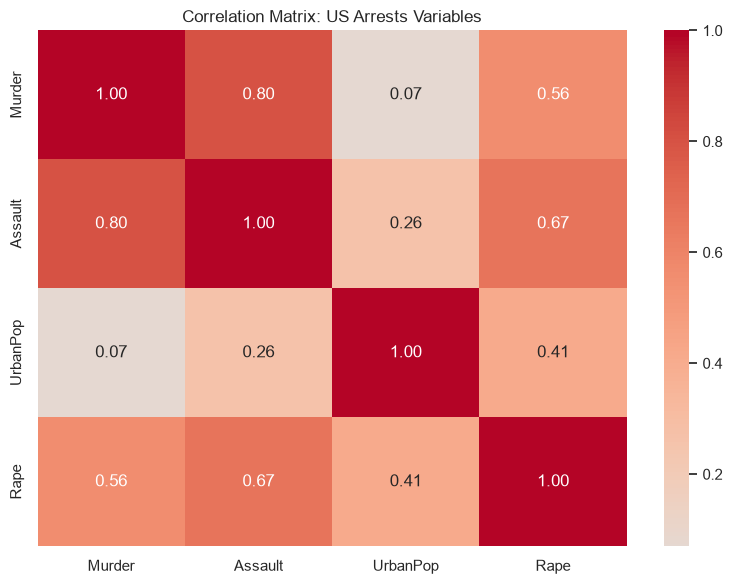

Correlation matrix:
           Murder  Assault  UrbanPop   Rape
Murder     1.000    0.802     0.070  0.564
Assault    0.802    1.000     0.259  0.665
UrbanPop   0.070    0.259     1.000  0.411
Rape       0.564    0.665     0.411  1.000

Interpretation:
Strongest linear relationship: Murder vs Assault (r = 0.802).
Positive values mean variables tend to increase together; negative values would indicate opposite movement.


In [3]:
def correlation_analysis(data: pd.DataFrame) -> pd.DataFrame:
    """Compute and plot the correlation matrix."""
    corr_matrix = data.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlation Matrix: US Arrests Variables")
    plt.tight_layout()
    plt.show()

    return corr_matrix


correlations = correlation_analysis(us_arrests)
print("Correlation matrix:\n", correlations.round(3))

upper_triangle = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
strongest_pair = upper_triangle.stack().abs().idxmax()
strongest_value = correlations.loc[strongest_pair[0], strongest_pair[1]]

print("\nInterpretation:")
print(f"Strongest linear relationship: {strongest_pair[0]} vs {strongest_pair[1]} (r = {strongest_value:.3f}).")
print("Positive values mean variables tend to increase together; negative values would indicate opposite movement.")

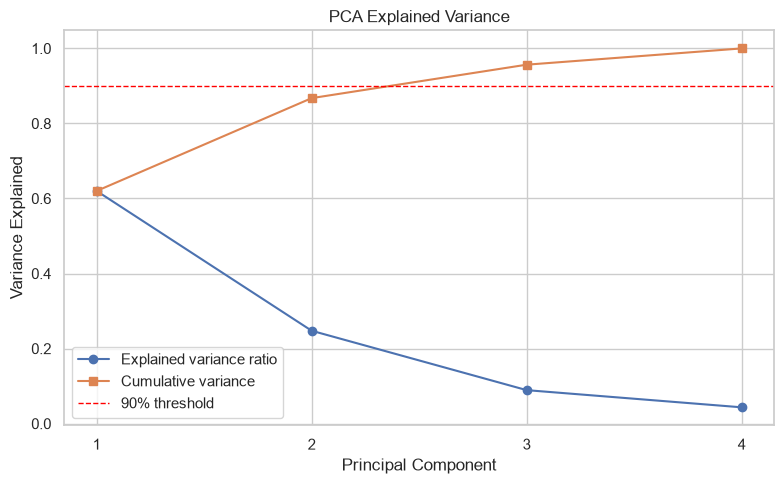

Explained variance table:
      Explained Variance Ratio  Cumulative Variance
PC1                     0.620                0.620
PC2                     0.247                0.868
PC3                     0.089                0.957
PC4                     0.043                1.000

PCA loadings (feature contributions):
             PC1    PC2    PC3
Murder    0.536 -0.418 -0.341
Assault   0.583 -0.188 -0.268
UrbanPop  0.278  0.873 -0.378
Rape      0.543  0.167  0.818


In [4]:
def run_pca(scaled_array: np.ndarray, feature_names: list[str]) -> tuple[PCA, pd.DataFrame, pd.DataFrame]:
    """Fit PCA and return model, component scores, and loading matrix."""
    pca_model = PCA()
    component_scores = pca_model.fit_transform(scaled_array)

    pc_columns = [f"PC{i + 1}" for i in range(component_scores.shape[1])]
    scores_df = pd.DataFrame(component_scores, columns=pc_columns, index=us_arrests.index)

    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        index=feature_names,
        columns=pc_columns,
    )
    return pca_model, scores_df, loadings_df


def plot_explained_variance(pca_model: PCA) -> None:
    """Plot explained variance ratio and cumulative explained variance."""
    explained = pca_model.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained) + 1), explained, marker="o", label="Explained variance ratio")
    plt.plot(range(1, len(cumulative) + 1), cumulative, marker="s", label="Cumulative variance")
    plt.axhline(0.90, color="red", linestyle="--", linewidth=1, label="90% threshold")
    plt.xticks(range(1, len(explained) + 1))
    plt.xlabel("Principal Component")
    plt.ylabel("Variance Explained")
    plt.title("PCA Explained Variance")
    plt.legend()
    plt.tight_layout()
    plt.show()


pca, pca_scores, pca_loadings = run_pca(us_arrests_scaled, us_arrests.columns.tolist())
plot_explained_variance(pca)

variance_table = pd.DataFrame(
    {
        "Explained Variance Ratio": pca.explained_variance_ratio_,
        "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_),
    },
    index=[f"PC{i + 1}" for i in range(len(pca.explained_variance_ratio_))],
)

print("Explained variance table:\n", variance_table.round(3))
print("\nPCA loadings (feature contributions):\n", pca_loadings.iloc[:, :3].round(3))

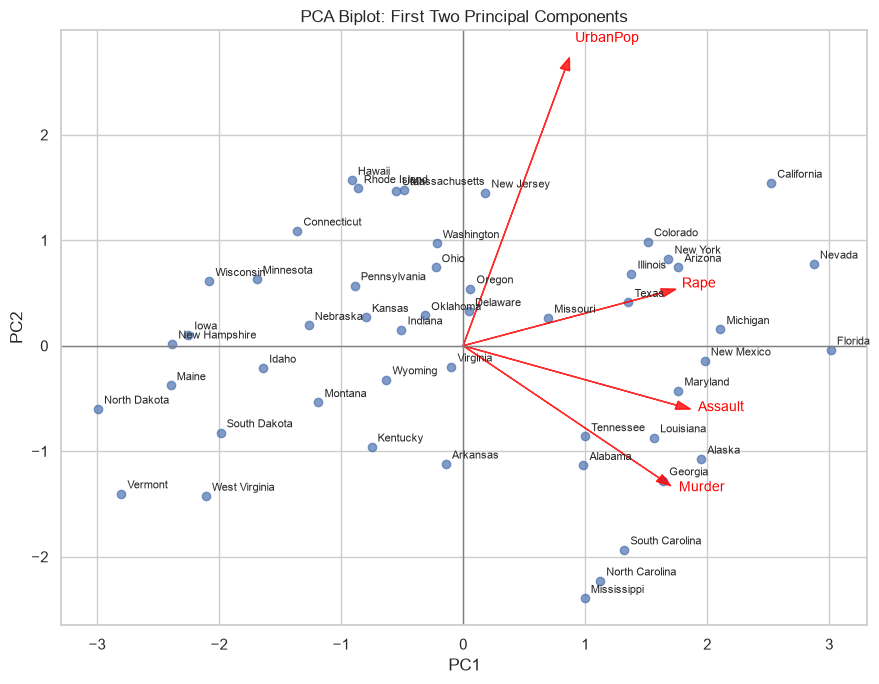

Biplot interpretation:
PC1 is mainly influenced by: Assault, Rape.
PC2 is mainly influenced by: UrbanPop, Murder.
States in the same direction of a variable arrow tend to have higher values for that variable.


In [5]:
def plot_biplot(scores_df: pd.DataFrame, loadings_df: pd.DataFrame, scale_factor: float = 3.0) -> None:
    """Plot a PCA biplot for the first two principal components."""
    plt.figure(figsize=(9, 7))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.7)

    for city_name, row in scores_df[["PC1", "PC2"]].iterrows():
        plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, city_name, fontsize=8)

    for feature_name in loadings_df.index:
        x_loading = loadings_df.loc[feature_name, "PC1"] * scale_factor
        y_loading = loadings_df.loc[feature_name, "PC2"] * scale_factor
        plt.arrow(0, 0, x_loading, y_loading, color="red", alpha=0.8, head_width=0.08)
        plt.text(x_loading * 1.1, y_loading * 1.1, feature_name, color="red", fontsize=10)

    plt.axhline(0, color="grey", linewidth=1)
    plt.axvline(0, color="grey", linewidth=1)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Biplot: First Two Principal Components")
    plt.tight_layout()
    plt.show()


plot_biplot(pca_scores, pca_loadings)

pc1_top = pca_loadings["PC1"].abs().sort_values(ascending=False).head(2).index.tolist()
pc2_top = pca_loadings["PC2"].abs().sort_values(ascending=False).head(2).index.tolist()

print("Biplot interpretation:")
print(f"PC1 is mainly influenced by: {', '.join(pc1_top)}.")
print(f"PC2 is mainly influenced by: {', '.join(pc2_top)}.")
print("States in the same direction of a variable arrow tend to have higher values for that variable.")

In [6]:
def choose_components(pca_model: PCA, variance_threshold: float = 0.90) -> int:
    """Select the smallest number of components that reaches a variance threshold."""
    cumulative = np.cumsum(pca_model.explained_variance_ratio_)
    n_components = int(np.argmax(cumulative >= variance_threshold) + 1)
    return n_components


selected_components = choose_components(pca, variance_threshold=0.90)
selected_variance = np.cumsum(pca.explained_variance_ratio_)[selected_components - 1]

print("Selected number of components:", selected_components)
print(f"Cumulative explained variance at selected components: {selected_variance:.3f}")
print(
    "Justification: This is the smallest number of principal components that preserves at least "
    "90% of the total variance for further analysis."
)

pca_reduced = PCA(n_components=selected_components)
reduced_scores = pca_reduced.fit_transform(us_arrests_scaled)
reduced_df = pd.DataFrame(
    reduced_scores,
    index=us_arrests.index,
    columns=[f"PC{i + 1}" for i in range(selected_components)],
)

Selected number of components: 3
Cumulative explained variance at selected components: 0.957
Justification: This is the smallest number of principal components that preserves at least 90% of the total variance for further analysis.


In [7]:
def choose_k_with_silhouette(data: np.ndarray, k_min: int = 2, k_max: int = 6) -> tuple[int, dict[int, float]]:
    """Select k by maximizing silhouette score for K-Means."""
    scores = {}
    for k in range(k_min, k_max + 1):
        model = KMeans(n_clusters=k, n_init=20, random_state=42)
        labels = model.fit_predict(data)
        scores[k] = silhouette_score(data, labels)

    best_k = max(scores, key=scores.get)
    return best_k, scores


def cluster_with_kmeans(data: np.ndarray, n_clusters: int) -> np.ndarray:
    """Apply K-Means clustering."""
    model = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    return model.fit_predict(data)


def cluster_with_agglomerative(data: np.ndarray, n_clusters: int) -> np.ndarray:
    """Apply Agglomerative (hierarchical) clustering."""
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    return model.fit_predict(data)


def summarize_clusters(original_data: pd.DataFrame, labels: np.ndarray, method_name: str) -> None:
    """Print cluster sizes and mean profiles."""
    cluster_frame = original_data.copy()
    cluster_frame["Cluster"] = labels

    print(f"\n{method_name} cluster sizes:")
    print(cluster_frame["Cluster"].value_counts().sort_index())

    print(f"\n{method_name} cluster mean profile:")
    print(cluster_frame.groupby("Cluster").mean(numeric_only=True).round(2))


best_k, silhouette_scores = choose_k_with_silhouette(reduced_scores)
kmeans_labels = cluster_with_kmeans(reduced_scores, best_k)
agg_labels = cluster_with_agglomerative(reduced_scores, best_k)

print("Silhouette scores (K-Means):", {k: round(v, 3) for k, v in silhouette_scores.items()})
print(f"Selected number of clusters (best silhouette): k = {best_k}")
print(f"K-Means silhouette at k={best_k}: {silhouette_score(reduced_scores, kmeans_labels):.3f}")
print(f"Agglomerative silhouette at k={best_k}: {silhouette_score(reduced_scores, agg_labels):.3f}")

summarize_clusters(us_arrests, kmeans_labels, "K-Means")
summarize_clusters(us_arrests, agg_labels, "Agglomerative")

Silhouette scores (K-Means): {2: 0.431, 3: 0.339, 4: 0.372, 5: 0.346, 6: 0.331}
Selected number of clusters (best silhouette): k = 2
K-Means silhouette at k=2: 0.431
Agglomerative silhouette at k=2: 0.427

K-Means cluster sizes:
Cluster
0    30
1    20
Name: count, dtype: int64

K-Means cluster mean profile:
         Murder  Assault  UrbanPop   Rape
Cluster                                  
0          4.87   114.43     63.63  15.94
1         12.16   255.25     68.40  29.16

Agglomerative cluster sizes:
Cluster
0    31
1    19
Name: count, dtype: int64

Agglomerative cluster mean profile:
         Murder  Assault  UrbanPop   Rape
Cluster                                  
0          5.00   116.48     63.84  16.34
1         12.33   259.32     68.32  29.22


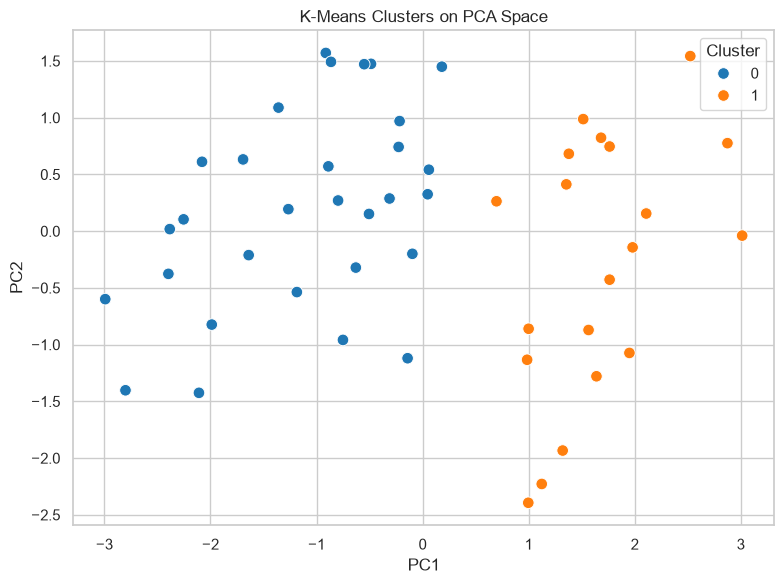

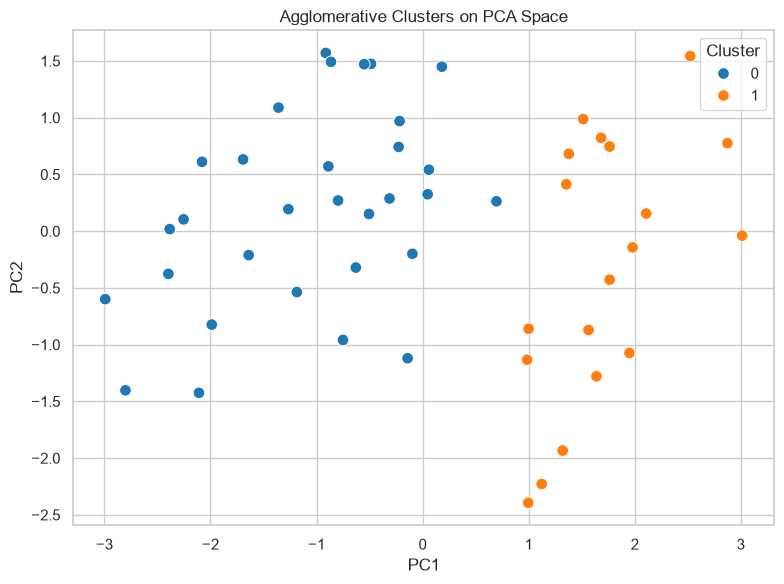

Cluster label comparison (first 15 states):
             KMeansCluster  AgglomerativeCluster
State                                           
Alabama                  1                     1
Alaska                   1                     1
Arizona                  1                     1
Arkansas                 0                     0
California               1                     1
Colorado                 1                     1
Connecticut              0                     0
Delaware                 0                     0
Florida                  1                     1
Georgia                  1                     1
Hawaii                   0                     0
Idaho                    0                     0
Illinois                 1                     1
Indiana                  0                     0
Iowa                     0                     0

Cluster analysis summary:
Within each method, states in the same cluster have similar arrest-rate profiles across Murder, 

In [8]:
def plot_cluster_scatter(scores_df: pd.DataFrame, labels: np.ndarray, title: str) -> None:
    """Plot first two principal components coloured by cluster label."""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=scores_df["PC1"], y=scores_df["PC2"], hue=labels, palette="tab10", s=70)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()


plot_cluster_scatter(reduced_df, kmeans_labels, "K-Means Clusters on PCA Space")
plot_cluster_scatter(reduced_df, agg_labels, "Agglomerative Clusters on PCA Space")

comparison_df = pd.DataFrame(
    {
        "State": us_arrests.index,
        "KMeansCluster": kmeans_labels,
        "AgglomerativeCluster": agg_labels,
    }
).set_index("State")

print("Cluster label comparison (first 15 states):")
print(comparison_df.head(15))

print("\nCluster analysis summary:")
print("Within each method, states in the same cluster have similar arrest-rate profiles across Murder, Assault, UrbanPop, and Rape.")
print("Both methods identify a high-crime grouping and one or more lower-crime groupings, with small membership differences.")